# NYC Taxi Analytics

## Análise de Demanda, Comportamento das Corridas e Otimização Operacional de Táxis em Nova York

Este projeto tem como objetivo analisar dados de corridas de táxi da cidade de Nova York, buscando identificar padrões de demanda, características das viagens e comportamentos relacionados a distância, duração e valores cobrados.

A análise será desenvolvida utilizando Python e Pandas para tratamento e exploração dos dados, SQL para consultas analíticas e Power BI para construção de dashboards interativos.

Em uma etapa posterior, os resultados da análise de demanda poderão ser utilizados como base para uma abordagem de otimização da distribuição operacional dos táxis.

## 1. Objetivos do projeto

### Objetivo geral

Analisar o comportamento das corridas de táxi em Nova York durante janeiro de 2016, identificando padrões de demanda, características das viagens e indicadores financeiros que possam apoiar análises operacionais.

### Objetivos específicos

- Avaliar a qualidade e consistência dos dados;
- Identificar e tratar registros inconsistentes;
- Analisar a demanda de corridas ao longo do dia;
- Comparar a demanda entre os dias da semana;
- Investigar a relação entre distância, duração e valor das corridas;
- Analisar indicadores relacionados à receita;
- Identificar períodos de maior demanda;
- Preparar os dados para consultas SQL e visualizações no Power BI;
- Explorar posteriormente uma possível aplicação de técnicas de otimização operacional.


## 2. Dataset

Os dados utilizados neste projeto correspondem aos registros de corridas de táxis amarelos (*Yellow Taxi*) de Nova York referentes a janeiro de 2016.

O conjunto de dados contém informações sobre:

- identificação do fornecedor;
- horário de início e término da corrida;
- número de passageiros;
- distância percorrida;
- localização de embarque e desembarque;
- tipo de tarifa;
- forma de pagamento;
- valor da tarifa;
- gorjeta;
- pedágios;
- valor total da corrida.

O arquivo utilizado no projeto é:

`yellow_tripdata_2016-01.csv`

A base original será preservada sem alterações. Durante o projeto será criada uma segunda versão contendo os dados tratados para análise.

## 3. Importação das bibliotecas

Nesta etapa são importadas as principais bibliotecas utilizadas no processo de análise e visualização dos dados.

A biblioteca Pandas será utilizada para manipulação dos dados, enquanto Matplotlib será utilizada para a construção dos primeiros gráficos exploratórios.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

## 4. Carregamento dos dados

O primeiro passo da análise consiste em carregar o arquivo CSV original para um DataFrame.

Neste momento, nenhum dado será alterado. A base carregada representa a versão original do dataset e será utilizada como referência durante todo o processo de limpeza.

In [6]:
df = pd.read_csv("yellow_tripdata_2016-01.csv")

print("Dados carregados com sucesso!")

Dados carregados com sucesso!


## 5. Conhecendo a base de dados

Antes de realizar qualquer tratamento, é importante compreender a estrutura do conjunto de dados.

Serão verificadas:

- quantidade de registros;
- quantidade de atributos;
- nomes das colunas;
- tipos de dados;
- primeiras observações.

Essa etapa permite obter uma visão inicial da estrutura da base.

In [7]:
print("Linhas:", df.shape[0])
print("Colunas:", df.shape[1])

print("\nColunas:")
print(df.columns.tolist())

Linhas: 10906858
Colunas: 19

Colunas:
['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'pickup_longitude', 'pickup_latitude', 'RatecodeID', 'store_and_fwd_flag', 'dropoff_longitude', 'dropoff_latitude', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount']


In [8]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,2,2016-01-01 00:00:00,2016-01-01 00:00:00,2,1.10,-73.990372,40.734695,1,N,-73.981842,40.732407,2,7.5,0.5,0.5,0.0,0.0,0.3,8.8
1,2,2016-01-01 00:00:00,2016-01-01 00:00:00,5,4.90,-73.980782,40.729912,1,N,-73.944473,40.716679,1,18.0,0.5,0.5,0.0,0.0,0.3,19.3
2,2,2016-01-01 00:00:00,2016-01-01 00:00:00,1,10.54,-73.984550,40.679565,1,N,-73.950272,40.788925,1,33.0,0.5,0.5,0.0,0.0,0.3,34.3
3,2,2016-01-01 00:00:00,2016-01-01 00:00:00,1,4.75,-73.993469,40.718990,1,N,-73.962242,40.657333,2,16.5,0.0,0.5,0.0,0.0,0.3,17.3
4,2,2016-01-01 00:00:00,2016-01-01 00:00:00,3,1.76,-73.960625,40.781330,1,N,-73.977264,40.758514,2,8.0,0.0,0.5,0.0,0.0,0.3,8.8


## 6. Tipos de dados

A identificação dos tipos de dados é importante para verificar se cada variável está representada adequadamente.

Em particular, as colunas de data e hora inicialmente são carregadas como texto e precisarão ser convertidas para o tipo `datetime` antes das análises temporais.

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10906858 entries, 0 to 10906857
Data columns (total 19 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   str    
 2   tpep_dropoff_datetime  str    
 3   passenger_count        int64  
 4   trip_distance          float64
 5   pickup_longitude       float64
 6   pickup_latitude        float64
 7   RatecodeID             int64  
 8   store_and_fwd_flag     str    
 9   dropoff_longitude      float64
 10  dropoff_latitude       float64
 11  payment_type           int64  
 12  fare_amount            float64
 13  extra                  float64
 14  mta_tax                float64
 15  tip_amount             float64
 16  tolls_amount           float64
 17  improvement_surcharge  float64
 18  total_amount           float64
dtypes: float64(12), int64(4), str(3)
memory usage: 1.5 GB


## 7. Análise de valores ausentes

A presença de valores ausentes pode afetar cálculos estatísticos, agrupamentos e visualizações.

Nesta etapa será verificada a quantidade de valores nulos em cada coluna.

In [10]:
df.isnull().sum()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
pickup_longitude         0
pickup_latitude          0
RatecodeID               0
store_and_fwd_flag       0
dropoff_longitude        0
dropoff_latitude         0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
dtype: int64

## 8. Verificação de registros duplicados

Registros duplicados podem distorcer métricas como quantidade de viagens e receita total.

Por isso, será verificada a existência de duplicatas exatas na base.

In [11]:
print("Duplicatas:", df.duplicated().sum())

Duplicatas: 1


## 9. Estatísticas descritivas

As estatísticas descritivas permitem observar a distribuição inicial das principais variáveis numéricas.

Serão analisadas medidas como:

- quantidade de observações;
- média;
- desvio padrão;
- valores mínimo e máximo;
- quartis.

Valores extremos serão investigados posteriormente antes de qualquer remoção.

In [12]:
df.describe()

,VendorID,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,1.090686e+07,1.090686e+07,1.090686e+07,1.090686e+07,1.090686e+07,1.090686e+07,1.090686e+07,1.090686e+07,1.090686e+07,1.090686e+07,1.090686e+07,1.090686e+07,1.090686e+07,1.090686e+07,1.090686e+07,1.090686e+07
mean,1.535024e+00,1.670847e+00,4.648197e+00,-7.281869e+01,4.011494e+01,1.039350e+00,-7.288659e+01,4.015315e+01,1.347536e+00,1.248693e+01,3.130757e-01,4.976705e-01,1.750663e+00,2.933453e-01,2.997245e-01,1.564140e+01
std,4.987718e-01,1.324891e+00,2.981095e+03,9.168964e+00,5.051022e+00,5.186309e-01,8.900841e+00,4.903456e+00,4.910804e-01,3.556400e+01,4.156792e-01,5.046685e-02,2.623546e+00,1.694572e+00,1.232553e-02,3.641280e+01
min,1.000000e+00,0.000000e+00,0.000000e+00,-1.219343e+02,0.000000e+00,1.000000e+00,-1.219335e+02,0.000000e+00,1.000000e+00,-9.576000e+02,-4.261000e+01,-5.000000e-01,-2.208000e+02,-1.740000e+01,-3.000000e-01,-9.584000e+02
25%,1.000000e+00,1.000000e+00,1.000000e+00,-7.399151e+01,4.073630e+01,1.000000e+00,-7.399107e+01,4.073481e+01,1.000000e+00,6.500000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,3.000000e-01,8.300000e+00
50%,2.000000e+00,1.000000e+00,1.670000e+00,-7.398138e+01,4.075369e+01,1.000000e+00,-7.397942e+01,4.075413e+01,1.000000e+00,9.000000e+00,0.000000e+00,5.000000e-01,1.260000e+00,0.000000e+00,3.000000e-01,1.162000e+01
75%,2.000000e+00,2.000000e+00,3.080000e+00,-7.396610e+01,4.076808e+01,1.000000e+00,-7.396196e+01,4.076962e+01,2.000000e+00,1.400000e+01,5.000000e-01,5.000000e-01,2.320000e+00,0.000000e+00,3.000000e-01,1.716000e+01
max,2.000000e+00,9.000000e+00,8.000010e+06,0.000000e+00,6.090876e+01,9.900000e+01,0.000000e+00,6.090876e+01,5.000000e+00,1.112709e+05,6.488700e+02,8.970000e+01,9.981400e+02,9.801500e+02,3.000000e-01,1.112716e+05


## 10. Distribuição do número de passageiros

A variável `passenger_count` representa a quantidade de passageiros informada para cada corrida.

A distribuição será analisada para identificar valores frequentes e possíveis valores atípicos.

In [13]:
df["passenger_count"].value_counts().sort_index()

passenger_count
0        520
1    7726984
2    1561977
3     436431
4     210641
5     601079
6     369155
7         22
8         26
9         23
Name: count, dtype: int64

## 11. Tratamento das variáveis temporais

As colunas `tpep_pickup_datetime` e `tpep_dropoff_datetime` representam, respectivamente, os horários de início e término das corridas.

Essas variáveis serão convertidas para o formato `datetime`, permitindo realizar operações temporais e calcular a duração das viagens.

In [14]:
df["tpep_pickup_datetime"] = pd.to_datetime(
    df["tpep_pickup_datetime"]
)

df["tpep_dropoff_datetime"] = pd.to_datetime(
    df["tpep_dropoff_datetime"]
)

## 11. Tratamento das variáveis temporais

As colunas `tpep_pickup_datetime` e `tpep_dropoff_datetime` representam, respectivamente, os horários de início e término das corridas.

Essas variáveis serão convertidas para o formato `datetime`, permitindo realizar operações temporais e calcular a duração das viagens.

In [15]:
df["tpep_pickup_datetime"] = pd.to_datetime(
    df["tpep_pickup_datetime"]
)

df["tpep_dropoff_datetime"] = pd.to_datetime(
    df["tpep_dropoff_datetime"]
)

## 12. Verificação do período dos dados

Será verificado o intervalo temporal presente na base, considerando os horários de início e término das corridas.

O dataset utilizado corresponde a janeiro de 2016.

In [16]:
print("Início do pickup:", df["tpep_pickup_datetime"].min())
print("Fim do pickup:", df["tpep_pickup_datetime"].max())

print("\nInício do dropoff:", df["tpep_dropoff_datetime"].min())
print("Fim do dropoff:", df["tpep_dropoff_datetime"].max())

Início do pickup: 2016-01-01 00:00:00
Fim do pickup: 2016-01-31 23:59:59

Início do dropoff: 2016-01-01 00:00:00
Fim do dropoff: 2016-03-28 12:54:26


## 13. Criação da variável de duração

A duração da corrida será calculada a partir da diferença entre o horário de término e o horário de início.

A nova variável `duration_min` representa a duração da viagem em minutos.

Essa variável será utilizada posteriormente para analisar o comportamento das viagens e identificar registros temporalmente inconsistentes.

In [17]:
df["duration_min"] = (
    df["tpep_dropoff_datetime"]
    - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

df["duration_min"].describe()

count    1.090686e+07
mean     1.526881e+01
std      8.690711e+01
min     -4.395000e+01
25%      6.333333e+00
50%      1.046667e+01
75%      1.688333e+01
max      1.199127e+05
Name: duration_min, dtype: float64

## 14. Identificação de inconsistências

A análise inicial dos dados identificou diferentes tipos de inconsistências:

- durações negativas ou iguais a zero;
- valores totais negativos ou iguais a zero;
- distâncias iguais a zero;
- distâncias extremamente elevadas;
- tarifas extremamente elevadas;
- registros cujo horário de término está fora do período analisado.

Esses problemas serão tratados por meio de regras explícitas de limpeza.

A coluna `passenger_count` com valor igual a zero será mantida, pois esse valor não será considerado, isoladamente, suficiente para caracterizar um registro inválido.

## 15. Definição das regras de limpeza

Para construir uma base adequada às análises posteriores, serão aplicadas as seguintes regras:

1. Remover corridas com duração menor ou igual a zero;
2. Remover corridas com `total_amount` menor ou igual a zero;
3. Remover corridas com `trip_distance` menor ou igual a zero;
4. Remover corridas cujo horário de término esteja fora de janeiro de 2016;
5. Remover registros com distância superior a 100 milhas, considerados incompatíveis com o contexto das corridas analisadas;
6. Remover registros com tarifa superior a US$ 1.000, considerados valores extremos e inconsistentes para a análise;
7. Remover duplicatas exatas.

A base original será preservada. As regras serão aplicadas apenas para gerar uma nova base destinada às análises.

In [18]:
inicio = pd.Timestamp("2016-01-01")
fim = pd.Timestamp("2016-01-31 23:59:59")

regra_duracao = df["duration_min"] <= 0

regra_valor = df["total_amount"] <= 0

regra_distancia = df["trip_distance"] <= 0

regra_dropoff = (
    (df["tpep_dropoff_datetime"] < inicio) |
    (df["tpep_dropoff_datetime"] > fim)
)

regra_distancia_extrema = df["trip_distance"] > 100

regra_tarifa_extrema = df["fare_amount"] > 1000

In [19]:
problema = (
    regra_duracao |
    regra_valor |
    regra_distancia |
    regra_dropoff |
    regra_distancia_extrema |
    regra_tarifa_extrema
)

print("Registros problemáticos:", problema.sum())

Registros problemáticos: 70260


## 16. Criação da base limpa

Os registros identificados pelas regras anteriores serão removidos da base destinada à análise.

É importante destacar que essa operação não altera o arquivo original. O DataFrame `df` permanece representando os dados originais, enquanto `df_clean` será utilizado nas etapas seguintes.

In [20]:
df_clean = df.loc[~problema].copy()

print("Registros originais:", len(df))
print("Registros após limpeza:", len(df_clean))
print(
    "Percentual mantido:",
    round(len(df_clean) / len(df) * 100, 4),
    "%"
)

Registros originais: 10906858
Registros após limpeza: 10836598
Percentual mantido: 99.3558 %


In [21]:
antes = len(df_clean)

df_clean = df_clean.drop_duplicates()

duplicatas_removidas = antes - len(df_clean)

print("Duplicatas removidas:", duplicatas_removidas)

Duplicatas removidas: 0


## 17. Validação da base limpa

Após a aplicação das regras, a base será novamente verificada para confirmar se os principais problemas identificados na etapa de diagnóstico foram tratados.

Também será verificada a presença de valores nulos.

In [22]:
print("========== VALIDAÇÃO ==========")

print("Linhas:", len(df_clean))
print("Colunas:", len(df_clean.columns))

print("\nValores nulos:")
print(df_clean.isnull().sum().sum())

print("\nDuração <= 0:")
print((df_clean["duration_min"] <= 0).sum())

print("\nTotal <= 0:")
print((df_clean["total_amount"] <= 0).sum())

print("\nDistância <= 0:")
print((df_clean["trip_distance"] <= 0).sum())

print("\nDistância > 100:")
print((df_clean["trip_distance"] > 100).sum())

print("\nTarifa > 1000:")
print((df_clean["fare_amount"] > 1000).sum())

========== VALIDAÇÃO ==========
Linhas: 10836598
Colunas: 20

Valores nulos:
0

Duração <= 0:
0

Total <= 0:
0

Distância <= 0:
0

Distância > 100:
0

Tarifa > 1000:
0


## 18. Estatísticas após a limpeza

Com a base limpa, serão recalculadas as estatísticas descritivas para observar como a remoção dos registros inconsistentes afetou a distribuição das principais variáveis.

Essa comparação permite verificar se valores extremos estavam distorcendo medidas como média e desvio padrão.

In [23]:
df_clean[
    [
        "passenger_count",
        "trip_distance",
        "fare_amount",
        "tip_amount",
        "tolls_amount",
        "total_amount",
        "duration_min"
    ]
].describe()

,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount,total_amount,duration_min
count,1.083660e+07,1.083660e+07,1.083660e+07,1.083660e+07,1.083660e+07,1.083660e+07,1.083660e+07
mean,1.672534e+00,2.914549e+00,1.242879e+01,1.744881e+00,2.914504e-01,1.557763e+01,1.520410e+01
std,1.326379e+00,3.609756e+00,1.052816e+01,2.481154e+00,1.643627e+00,1.302057e+01,5.654826e+01
min,0.000000e+00,1.000000e-02,0.000000e+00,-2.380000e+01,0.000000e+00,3.000000e-01,1.666667e-02
25%,1.000000e+00,1.000000e+00,6.500000e+00,0.000000e+00,0.000000e+00,8.300000e+00,6.400000e+00
50%,1.000000e+00,1.690000e+00,9.000000e+00,1.260000e+00,0.000000e+00,1.162000e+01,1.051667e+01
75%,2.000000e+00,3.100000e+00,1.400000e+01,2.320000e+00,0.000000e+00,1.716000e+01,1.693333e+01
max,9.000000e+00,9.930000e+01,9.989000e+02,9.981400e+02,9.801500e+02,1.298950e+03,3.712687e+04


## 19. Exportação da base tratada

Após a validação, a base limpa será exportada para um novo arquivo CSV.

O arquivo original será mantido separadamente para garantir a rastreabilidade do processo de tratamento.

**Arquivo original:** `yellow_tripdata_2016-01.csv`

**Arquivo tratado:** `yellow_tripdata_2016-01_clean.csv`

In [24]:
df_clean.to_csv(
    "yellow_tripdata_2016-01_clean.csv",
    index=False
)

print("Base limpa exportada com sucesso!")

Base limpa exportada com sucesso!


# 20. Análise Exploratória dos Dados (EDA)

Com a base devidamente tratada, inicia-se a etapa de análise exploratória.

O objetivo agora é transformar os registros individuais em informações capazes de responder perguntas sobre o comportamento do serviço de táxis.

As primeiras análises serão direcionadas à demanda:

- Quantas corridas ocorrem em cada hora?
- Quais dias da semana apresentam maior volume?
- Quais combinações de dia e horário concentram mais corridas?
- Como a demanda varia ao longo de janeiro?

Em seguida serão analisadas características das viagens e aspectos financeiros.

In [25]:
df_clean["pickup_date"] = df_clean["tpep_pickup_datetime"].dt.date
df_clean["pickup_hour"] = df_clean["tpep_pickup_datetime"].dt.hour
df_clean["pickup_weekday"] = df_clean["tpep_pickup_datetime"].dt.day_name()
df_clean["pickup_day"] = df_clean["tpep_pickup_datetime"].dt.day

dias = {
    "Monday": "Segunda-feira",
    "Tuesday": "Terça-feira",
    "Wednesday": "Quarta-feira",
    "Thursday": "Quinta-feira",
    "Friday": "Sexta-feira",
    "Saturday": "Sábado",
    "Sunday": "Domingo"
}

df_clean["pickup_weekday"] = df_clean["pickup_weekday"].map(dias)

df_clean[[
    "tpep_pickup_datetime",
    "pickup_date",
    "pickup_hour",
    "pickup_weekday",
    "pickup_day"
]].head()

,tpep_pickup_datetime,pickup_date,pickup_hour,pickup_weekday,pickup_day
5,2016-01-01 00:00:00,2016-01-01,0,Sexta-feira,1
6,2016-01-01 00:00:00,2016-01-01,0,Sexta-feira,1
7,2016-01-01 00:00:01,2016-01-01,0,Sexta-feira,1
8,2016-01-01 00:00:02,2016-01-01,0,Sexta-feira,1
9,2016-01-01 00:00:02,2016-01-01,0,Sexta-feira,1


## 20.2 Demanda por hora

A primeira análise busca identificar como a demanda por corridas varia ao longo do dia.

Para isso, será contabilizada a quantidade de corridas iniciadas em cada hora do dia.

Essa análise permite identificar os períodos de maior e menor demanda, fornecendo uma visão inicial do comportamento temporal do serviço.

In [26]:
demanda_hora = (
    df_clean
    .groupby("pickup_hour")
    .size()
    .reset_index(name="total_corridas")
)

demanda_hora

,pickup_hour,total_corridas
0,0,392793
1,1,297680
2,2,227035
3,3,167103
4,4,123653
5,5,109899
6,6,234229
7,7,402241
8,8,489038
9,9,489443


### Demanda de corridas ao longo do dia

A distribuição horária da quantidade de corridas será representada graficamente para facilitar a identificação dos períodos de maior e menor demanda.

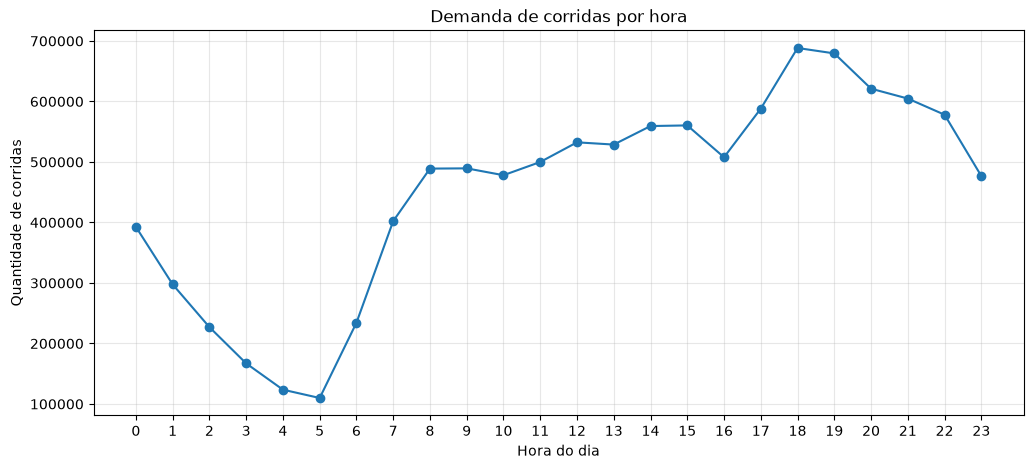

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    demanda_hora["pickup_hour"],
    demanda_hora["total_corridas"],
    marker="o"
)

plt.title("Demanda de corridas por hora")
plt.xlabel("Hora do dia")
plt.ylabel("Quantidade de corridas")
plt.xticks(range(24))
plt.grid(True, alpha=0.3)

plt.show()

## 20.3 Interpretação da demanda por hora

A distribuição das corridas apresenta um comportamento bastante distinto entre a madrugada, o período diurno e a noite.

Durante a madrugada, observa-se uma redução progressiva da demanda, atingindo seu menor nível por volta das 5 horas. A partir das primeiras horas da manhã, a quantidade de corridas aumenta significativamente.

Ao longo do período diurno, a demanda permanece elevada, apresentando algumas oscilações. O crescimento se intensifica novamente no final da tarde, alcançando os maiores volumes entre aproximadamente 18 e 19 horas.

Após esse período, a demanda começa a diminuir gradualmente durante a noite.

De forma geral, os dados indicam uma forte variação da demanda ao longo do dia, com períodos de baixa demanda durante a madrugada e maior concentração de corridas no final da tarde e início da noite.

## 20.4 Demanda por dia da semana

Além da variação ao longo das horas, a demanda também pode apresentar diferenças entre os dias da semana.

Nesta análise será contabilizada a quantidade de corridas iniciadas em cada dia da semana, permitindo identificar possíveis diferenças entre os dias úteis e o final de semana.

In [28]:
demanda_dia_semana = (
    df_clean
    .groupby("pickup_weekday")
    .size()
    .reindex([
        "Segunda-feira",
        "Terça-feira",
        "Quarta-feira",
        "Quinta-feira",
        "Sexta-feira",
        "Sábado",
        "Domingo"
    ])
    .reset_index(name="total_corridas")
)

demanda_dia_semana

,pickup_weekday,total_corridas
0,Segunda-feira,1273721
1,Terça-feira,1414463
2,Quarta-feira,1475962
3,Quinta-feira,1535271
4,Sexta-feira,1960624
5,Sábado,1633901
6,Domingo,1542656


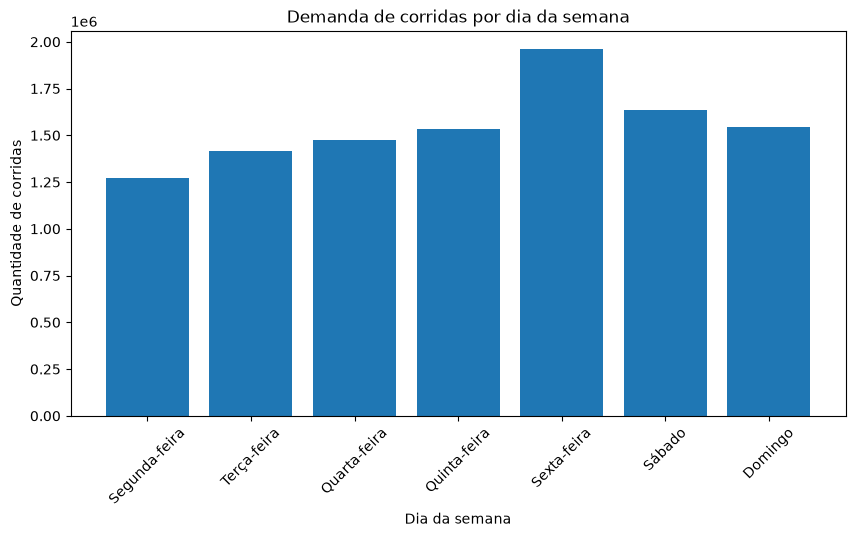

In [29]:
plt.figure(figsize=(10, 5))

plt.bar(
    demanda_dia_semana["pickup_weekday"],
    demanda_dia_semana["total_corridas"]
)

plt.title("Demanda de corridas por dia da semana")
plt.xlabel("Dia da semana")
plt.ylabel("Quantidade de corridas")
plt.xticks(rotation=45)

plt.show()

## 20.5 Interpretação da demanda por dia da semana

A quantidade de corridas apresenta diferenças relevantes entre os dias da semana.

A sexta-feira concentra o maior volume de corridas, ultrapassando 1,9 milhão de viagens no período analisado. Em seguida, aparecem o sábado e o domingo, com volumes superiores aos observados na maior parte dos dias úteis.

A segunda-feira apresenta o menor volume de corridas entre os dias analisados. A partir dela, observa-se um crescimento gradual da demanda ao longo da semana, atingindo seu maior nível na sexta-feira.

Os resultados indicam que a demanda não varia apenas de acordo com o horário, mas também apresenta diferenças relacionadas ao dia da semana. Dessa forma, a análise conjunta dessas duas dimensões pode fornecer uma visão mais detalhada dos períodos de maior concentração de corridas.

## 20.6 Demanda por dia da semana e hora

As análises anteriores mostraram que a quantidade de corridas varia tanto ao longo do dia quanto entre os dias da semana.

Nesta etapa, essas duas dimensões serão analisadas conjuntamente.

Será construída uma matriz contendo a quantidade de corridas para cada combinação entre dia da semana e hora do dia. Essa abordagem permite identificar períodos específicos de maior ou menor concentração da demanda.

In [30]:
demanda_dia_hora = (
    df_clean
    .groupby(["pickup_weekday", "pickup_hour"])
    .size()
    .unstack(fill_value=0)
    .reindex([
        "Segunda-feira",
        "Terça-feira",
        "Quarta-feira",
        "Quinta-feira",
        "Sexta-feira",
        "Sábado",
        "Domingo"
    ])
)

demanda_dia_hora

pickup_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
pickup_weekday,,,,,,,,,,,,,,,,,,,,,
Segunda-feira,28070,18001,12048,8456,9094,13505,33200,54534,66915,65034,...,69304,72144,67126,79064,90890,86910,77616,70810,62207,41979
Terça-feira,30127,17081,10053,6880,7504,14885,40907,74178,87083,78862,...,72157,73441,64214,76709,93592,91011,88101,86835,76301,52533
Quarta-feira,33156,19183,11888,8282,8490,14482,40865,74408,87437,79625,...,74202,73738,63690,79068,97763,98818,94797,93323,84881,61925
Quinta-feira,37942,22572,14288,9495,9068,14969,41848,75231,87306,80015,...,78069,75856,64371,78835,98611,101862,97778,98364,92208,75161
Sexta-feira,77776,61672,47158,35625,27946,23714,45661,78598,91792,85850,...,98101,93709,82871,99714,119576,122800,108559,106025,110120,105798
Sábado,95507,80162,63868,46982,29306,14260,17388,25212,37255,53671,...,79203,82004,78089,85634,94793,96381,82619,81562,89815,92639
Domingo,90215,79009,67732,51383,32245,14084,14360,20080,31250,46386,...,88334,89532,87419,89116,93147,81661,71652,67862,62556,46656


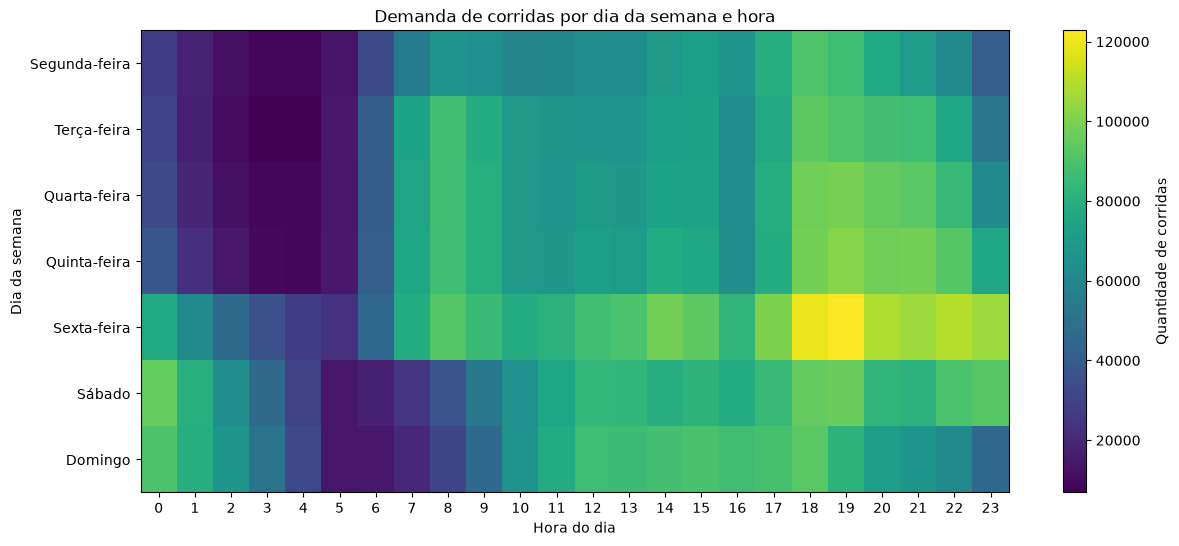

In [31]:
plt.figure(figsize=(14, 6))

plt.imshow(
    demanda_dia_hora,
    aspect="auto"
)

plt.colorbar(label="Quantidade de corridas")

plt.xticks(
    range(24),
    range(24)
)

plt.yticks(
    range(7),
    demanda_dia_hora.index
)

plt.xlabel("Hora do dia")
plt.ylabel("Dia da semana")
plt.title("Demanda de corridas por dia da semana e hora")

plt.show()

## 20.7 Interpretação da demanda por dia da semana e hora

A análise conjunta entre o dia da semana e a hora do dia permite identificar períodos específicos de concentração da demanda.

Durante a madrugada, observa-se uma demanda relativamente baixa na maior parte dos dias, especialmente entre aproximadamente 2h e 5h. A partir das primeiras horas da manhã, a quantidade de corridas aumenta de forma significativa.

Nos dias úteis, a demanda permanece elevada durante o período diurno e apresenta uma concentração mais evidente no final da tarde e início da noite. Esse comportamento é especialmente acentuado às sextas-feiras, que apresentam os maiores volumes de corridas em diversos horários entre o final da tarde e a noite.

Durante o final de semana, o padrão apresenta algumas diferenças em relação aos dias úteis. Sábado e domingo apresentam níveis elevados de demanda durante parte da madrugada e do período diurno, enquanto os horários de menor demanda permanecem concentrados principalmente nas primeiras horas da manhã.

O heatmap evidencia, portanto, que a demanda possui um comportamento dependente tanto do horário quanto do dia da semana. Essa característica será relevante para análises posteriores de distribuição e planejamento operacional.

## 20.8 Evolução diária da demanda

Após analisar a demanda por hora e por dia da semana, será investigada sua evolução ao longo do mês de janeiro de 2016.

A quantidade de corridas será agregada por dia, permitindo observar variações na demanda durante o período analisado e identificar dias que apresentem volumes significativamente diferentes.

In [34]:
demanda_diaria = (
    df_clean
    .groupby("pickup_date")
    .size()
    .reset_index(name="total_corridas")
)

demanda_diaria.head()

,pickup_date,total_corridas
0,2016-01-01,342553
1,2016-01-02,310898
2,2016-01-03,300729
3,2016-01-04,314108
4,2016-01-05,341115


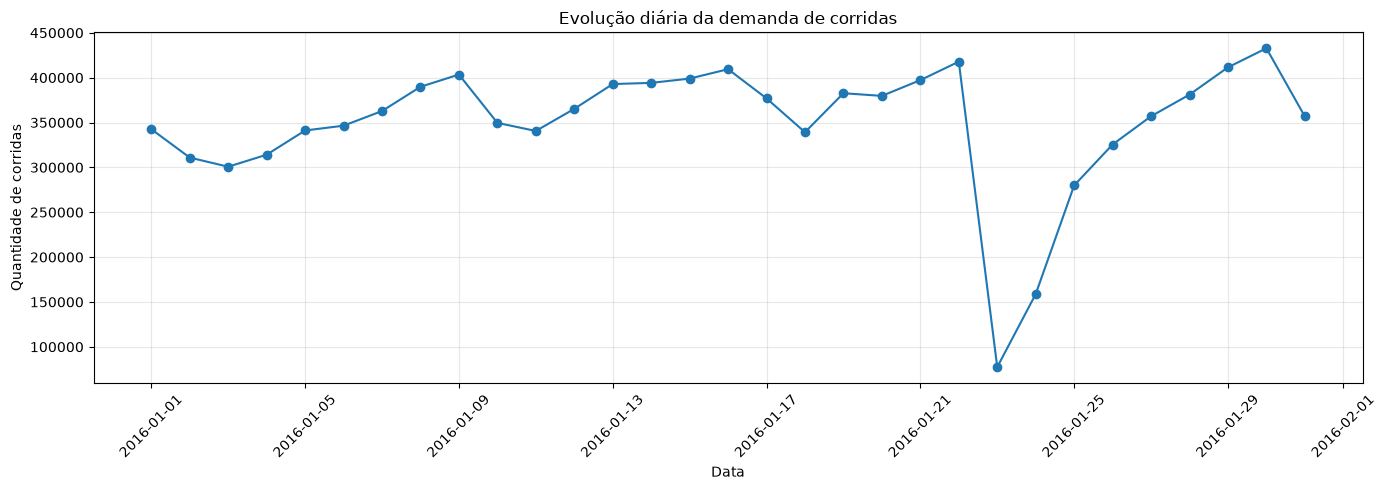

In [35]:
plt.figure(figsize=(14, 5))

plt.plot(
    demanda_diaria["pickup_date"],
    demanda_diaria["total_corridas"],
    marker="o"
)

plt.title("Evolução diária da demanda de corridas")
plt.xlabel("Data")
plt.ylabel("Quantidade de corridas")

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 20.9 Investigação de variações na demanda

A evolução diária apresenta uma queda acentuada no volume de corridas em um dos dias do período analisado.

Antes de interpretar essa redução como uma alteração real no comportamento da demanda, será verificado o número de registros disponíveis para cada dia e a distribuição das corridas ao longo das horas.

Essa verificação permite avaliar se a redução observada está relacionada à própria demanda ou a alguma característica dos dados.

In [36]:
demanda_diaria.sort_values(
    "total_corridas"
).head(5)

,pickup_date,total_corridas
22,2016-01-23,77383
23,2016-01-24,158710
24,2016-01-25,279857
2,2016-01-03,300729
1,2016-01-02,310898


In [37]:
demanda_diaria.sort_values(
    "total_corridas",
    ascending=False
).head(5)

,pickup_date,total_corridas
29,2016-01-30,432745
21,2016-01-22,417805
28,2016-01-29,411506
15,2016-01-16,409425
8,2016-01-09,403450


In [38]:
df_clean[df_clean["pickup_day"] == 23]["pickup_hour"].value_counts().sort_index()

pickup_hour
0     18853
1     13808
2     10274
3      7791
4      4183
5      1562
6      1533
7      1772
8      1973
9      2291
10     2645
11     3021
12     2962
13     2529
14     1268
15      578
16      177
17       62
18       42
19       16
20        7
21       10
22       11
23       15
Name: count, dtype: int64

## 20.10 Comparação da demanda antes, durante e após a queda

Para compreender melhor a redução observada no dia 23 de janeiro, será realizada uma comparação entre os dias 22, 23 e 24.

A análise por hora permitirá verificar como a demanda se comportou imediatamente antes, durante e após a queda observada na série diária.

In [39]:
comparacao_22_23_24 = (
    df_clean[df_clean["pickup_day"].isin([22, 23, 24])]
    .groupby(["pickup_day", "pickup_hour"])
    .size()
    .unstack(fill_value=0)
)

comparacao_22_23_24

pickup_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
pickup_day,,,,,,,,,,,,,,,,,,,,,
22,14201,8745,5577,3764,3274,4217,10191,19109,22854,20713,...,21428,20542,17844,21864,26799,27849,23824,22928,23811,22025
23,18853,13808,10274,7791,4183,1562,1533,1772,1973,2291,...,1268,578,177,62,42,16,7,10,11,15
24,15,8,13,12,19,31,117,651,1404,2729,...,11963,12711,12413,13035,14942,13940,12166,11988,10959,7759


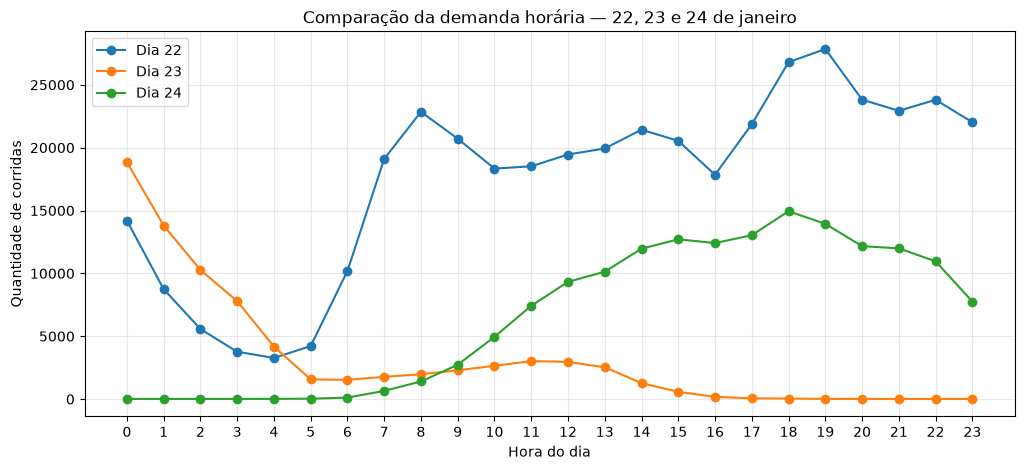

In [40]:
plt.figure(figsize=(12, 5))

for dia in [22, 23, 24]:
    dados_dia = comparacao_22_23_24.loc[dia]
    
    plt.plot(
        dados_dia.index,
        dados_dia.values,
        marker="o",
        label=f"Dia {dia}"
    )

plt.title("Comparação da demanda horária — 22, 23 e 24 de janeiro")
plt.xlabel("Hora do dia")
plt.ylabel("Quantidade de corridas")
plt.xticks(range(24))
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

### 20.10.1 Verificação dos horários disponíveis

A comparação entre os dias 22, 23 e 24 revelou um comportamento atípico na distribuição dos registros.

Para verificar se a queda observada representa uma alteração real na demanda ou uma ausência parcial de registros, serão analisados os primeiros e últimos horários de corrida disponíveis em cada um desses dias.

In [41]:
for dia in [22, 23, 24]:
    dados_dia = df_clean[df_clean["pickup_day"] == dia]
    
    print(f"\nDia {dia}")
    print("Primeira corrida:", dados_dia["tpep_pickup_datetime"].min())
    print("Última corrida:", dados_dia["tpep_pickup_datetime"].max())
    print("Total de corridas:", len(dados_dia))


Dia 22
Primeira corrida: 2016-01-22 00:00:00
Última corrida: 2016-01-22 23:59:59
Total de corridas: 417805

Dia 23
Primeira corrida: 2016-01-23 00:00:00
Última corrida: 2016-01-23 23:58:39
Total de corridas: 77383

Dia 24
Primeira corrida: 2016-01-24 00:00:36
Última corrida: 2016-01-24 23:59:59
Total de corridas: 158710


## 20.11 Interpretação da queda de demanda em 23 e 24 de janeiro

A evolução diária da demanda apresentou uma redução excepcional nos dias 23 e 24 de janeiro. A verificação dos registros mostrou que essa redução não está associada à ausência completa de dados durante esses dias: o dia 23 possui registros desde 00:00 até 23:58, totalizando 77.383 corridas, enquanto o dia 24 apresenta 158.710 corridas.

A redução observada coincide com um evento meteorológico significativo ocorrido em Nova York durante o período. Entre os dias 22 e 24 de janeiro de 2016, a região foi atingida por uma intensa tempestade de inverno, com condições de nevasca e grande acumulado de neve. O National Weather Service registrou condições de blizzard em Nova York e aproximadamente 27,5 polegadas de neve no Central Park.

Além disso, autoridades municipais emitiram recomendações para evitar deslocamentos durante o evento devido às condições adversas de viagem.

Dessa forma, a redução observada nas corridas nos dias 23 e 24 pode ser analisada como um comportamento excepcional associado às condições daquele período. Como os dados de corridas, isoladamente, não permitem estabelecer causalidade, o evento meteorológico será tratado como um possível fator contextual e não como uma explicação causal definitiva.

Esse comportamento também demonstra a importância de considerar eventos externos na análise de demanda, especialmente em aplicações relacionadas ao planejamento operacional.